# CIFAKE: Real vs AI-Generated Image Detection (CNN / ResNet-Style Classifier
This notebook builds an image classifier for the CIFAKE dataset.

## 1. Setup 

In [1]:
import os
import json
import random
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-05-24 14:32:07.896820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779633128.087654      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779633128.140301      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779633128.555575      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779633128.555611      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779633128.555614      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Config 

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Change this only if Kaggle shows a different dataset path.
DATASET_DIR = Path("/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images")

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

WORK_DIR = Path("/kaggle/working")
MODEL_DIR = WORK_DIR / "models"
REPORT_DIR = WORK_DIR / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# CIFAKE images are 32x32.
# We keep native resolution instead of resizing to 224x224.
IMG_SIZE = 32
BATCH_SIZE = 256
VALIDATION_SPLIT = 0.10

INITIAL_EPOCHS = 20
FINE_TUNE_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE

print("Dataset directory:", DATASET_DIR)
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Dataset directory: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
Train directory exists: True
Test directory exists: True


In [3]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)

    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled.")
    except Exception as e:
        print("Mixed precision not enabled:", e)
else:
    print("No GPU found. This notebook will run slower on CPU.")

GPU memory growth enabled.
Mixed precision enabled.


## 3. Build Image Manifest and DataFrame 

In [4]:
def build_manifest(split_name, directory):
    rows = []
    
    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue
        
        label = class_dir.name.upper()
        
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
            for path in class_dir.glob(ext):
                rows.append({
                    "split": split_name,
                    "label": label,
                    "path": str(path)
                })
    
    return pd.DataFrame(rows)


train_manifest = build_manifest("train", TRAIN_DIR)
test_manifest = build_manifest("test", TEST_DIR)

df = pd.concat([train_manifest, test_manifest], ignore_index=True)

df["model_label"] = df["label"].map({
    "REAL": 0,
    "FAKE": 1
})

assert df["model_label"].notna().all(), "Some labels could not be mapped."

df["model_label"] = df["model_label"].astype(int)

print("Manifest shape:", df.shape)
display(df.head())
display(pd.crosstab(df["split"], df["label"]))

Manifest shape: (120000, 4)


,split,label,path,model_label
0,train,FAKE,/kaggle/input/datasets/birdy654/cifake-real-an...,1
1,train,FAKE,/kaggle/input/datasets/birdy654/cifake-real-an...,1
2,train,FAKE,/kaggle/input/datasets/birdy654/cifake-real-an...,1
3,train,FAKE,/kaggle/input/datasets/birdy654/cifake-real-an...,1
4,train,FAKE,/kaggle/input/datasets/birdy654/cifake-real-an...,1


label,FAKE,REAL
split,,
test,10000,10000
train,50000,50000


## 4. Exploratory Data Analysis (EDA) 

### 4a. Label Distribution 

In [5]:
label_counts = df["label"].value_counts().sort_index()

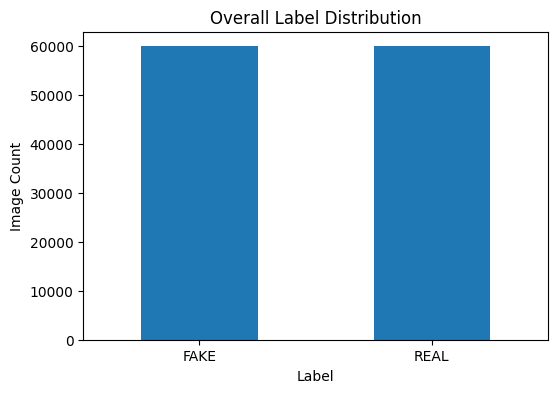

In [6]:
plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("Overall Label Distribution")
plt.xlabel("Label")
plt.ylabel("Image Count")
plt.xticks(rotation=0)
plt.show()

In [7]:
label_counts.to_frame("count")

,count
label,
FAKE,60000
REAL,60000


## 4b. Split Distribution 

label,FAKE,REAL
split,,
test,10000,10000
train,50000,50000


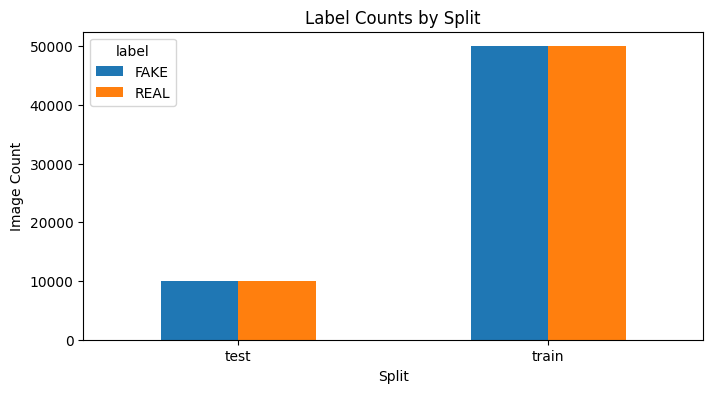

In [8]:
split_label_counts = pd.crosstab(df["split"], df["label"])

display(split_label_counts)

split_label_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Label Counts by Split")
plt.xlabel("Split")
plt.ylabel("Image Count")
plt.xticks(rotation=0)
plt.show()

## 4c. Image Size and Mode Audit
CIFAKE should mostly be 32x32 RGB. We verify that.

In [9]:
def inspect_image(path):
    try:
        with Image.open(path) as img:
            return {
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            }
    except Exception as e:
        return {
            "width": None,
            "height": None,
            "mode": f"ERROR: {str(e)[:80]}"
        }


sample_for_audit = df.sample(min(5000, len(df)), random_state=SEED).copy()

audit_rows = []

for path in sample_for_audit["path"]:
    audit_rows.append(inspect_image(path))

audit_df = pd.DataFrame(audit_rows)
audit_df["label"] = sample_for_audit["label"].values
audit_df["split"] = sample_for_audit["split"].values

display(audit_df.head())

print("Image sizes:")
display(audit_df.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False).head())

print("Image modes:")
display(audit_df["mode"].value_counts())

,width,height,mode,label,split
0,32,32,RGB,REAL,train
1,32,32,RGB,REAL,train
2,32,32,RGB,REAL,train
3,32,32,RGB,FAKE,train
4,32,32,RGB,FAKE,train


Image sizes:


,width,height,count
0,32,32,5000


Image modes:


mode
RGB    5000
Name: count, dtype: int64

## 5. Visualize Sample Images

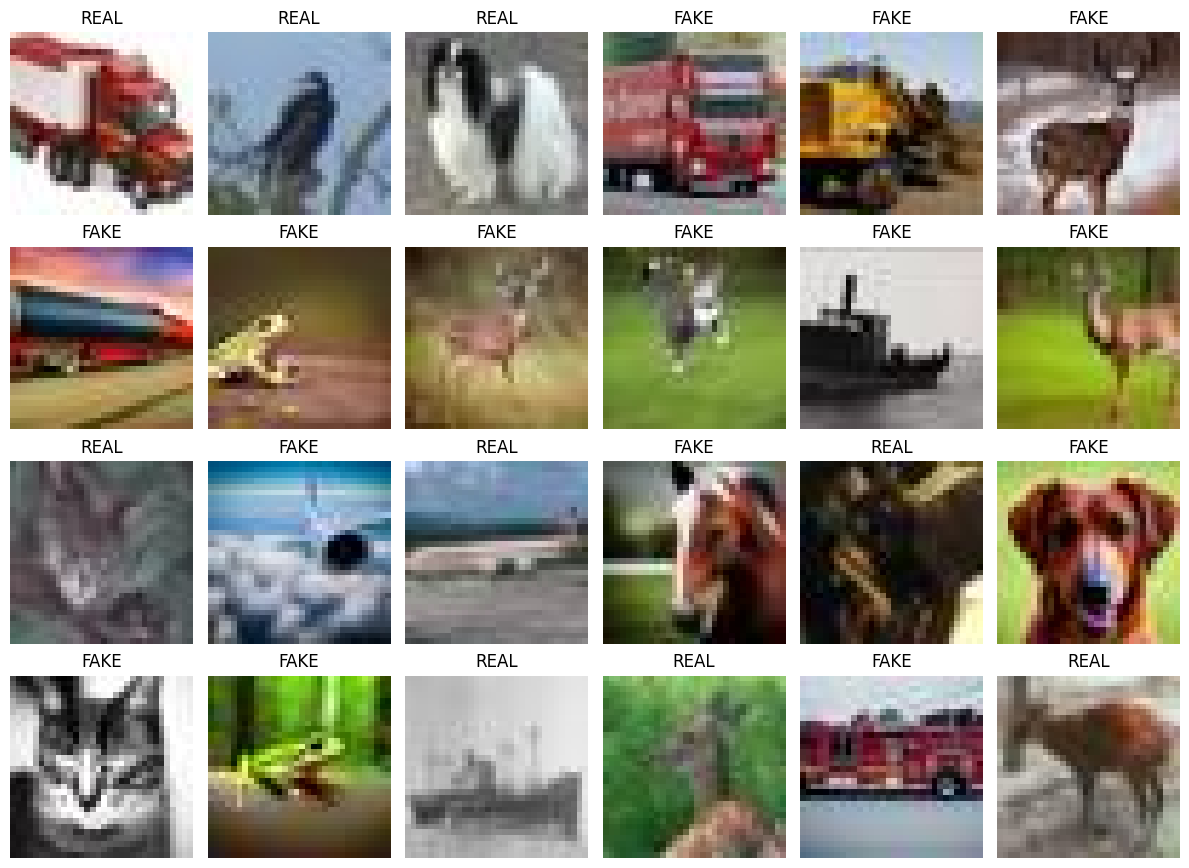

In [10]:
def show_sample_images(dataframe, n=24):
    sample_df = dataframe.sample(min(n, len(dataframe)), random_state=SEED)
    
    cols = 6
    rows = int(np.ceil(len(sample_df) / cols))
    
    plt.figure(figsize=(12, rows * 2.2))
    
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["label"])
    
    plt.tight_layout()
    plt.show()


show_sample_images(df, n=24)

## 6. Feature Analysis
Even though this is an image model, simple image statistics can reveal dataset artifacts.

We will calculate:
* Mean red, green, blue channels
* Brightness
* Contrast
* Edge strength approximation

This is not used directly in the main model. It is for dataset understanding.

In [11]:
def image_stats(path):
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img).astype(np.float32) / 255.0
    
    mean_r = arr[:, :, 0].mean()
    mean_g = arr[:, :, 1].mean()
    mean_b = arr[:, :, 2].mean()
    
    brightness = arr.mean()
    contrast = arr.std()
    
    # simple edge approximation
    gray = arr.mean(axis=2)
    dx = np.abs(np.diff(gray, axis=1)).mean()
    dy = np.abs(np.diff(gray, axis=0)).mean()
    edge_strength = dx + dy
    
    return {
        "mean_r": mean_r,
        "mean_g": mean_g,
        "mean_b": mean_b,
        "brightness": brightness,
        "contrast": contrast,
        "edge_strength": edge_strength
    }


stats_sample = df.sample(min(10000, len(df)), random_state=SEED).copy()

stats_rows = []

for i, path in enumerate(stats_sample["path"], start=1):
    stats_rows.append(image_stats(path))
    
    if i % 1000 == 0:
        print(f"Processed {i}/{len(stats_sample)}")

stats_df = pd.DataFrame(stats_rows)

Processed 1000/10000
Processed 2000/10000
Processed 3000/10000
Processed 4000/10000
Processed 5000/10000
Processed 6000/10000
Processed 7000/10000
Processed 8000/10000
Processed 9000/10000
Processed 10000/10000


In [12]:
stats_df["label"] = stats_sample["label"].values

In [13]:
stats_df["split"] = stats_sample["split"].values

In [14]:
stats_df.head()

,mean_r,mean_g,mean_b,brightness,contrast,edge_strength,label,split
0,0.678516,0.563457,0.547515,0.596496,0.326395,0.187380,REAL,train
1,0.455565,0.530760,0.608862,0.531729,0.189337,0.101165,REAL,train
2,0.533264,0.537891,0.523108,0.531421,0.217562,0.134505,REAL,train
3,0.480683,0.375310,0.373208,0.409734,0.195146,0.167048,FAKE,train
4,0.470485,0.417509,0.343061,0.410352,0.285446,0.135769,FAKE,train


### 6a. Statistics by Label

In [15]:
stats_df.groupby("label")[[
    "mean_r",
    "mean_g",
    "mean_b",
    "brightness",
    "contrast",
    "edge_strength"
]].describe()

mean_r                                                              \
        count      mean       std       min       25%       50%       75%   
label                                                                       
FAKE   5114.0  0.453343  0.077308  0.182939  0.400705  0.456311  0.506423   
REAL   4886.0  0.493348  0.128538  0.077949  0.409000  0.491709  0.572537   

                 mean_g            ...  contrast           edge_strength  \
            max   count      mean  ...       75%       max         count   
label                              ...                                     
FAKE   0.685195  5114.0  0.444705  ...  0.256201  0.382050        5114.0   
REAL   0.933004  4886.0  0.482541  ...  0.248039  0.402473        4886.0   

                                                                             
           mean       std       min       25%       50%       75%       max  
label                                                                        
FAKE   0.126766  0.041927  0.020558  0.096050  0.126830  0.155805  0.359796  
REAL   0.117058  0.034970  0.016008  0.093009  0.116095  0.140048  0.291036  

[2 rows x 48 columns]

### 6b. Brightness Distribution 

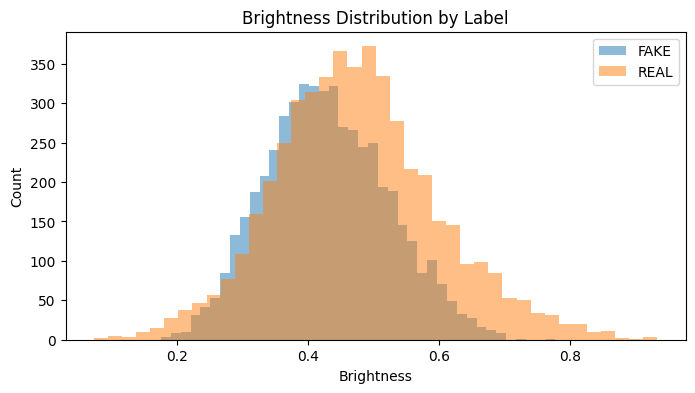

In [16]:
plt.figure(figsize=(8, 4))

for label in sorted(stats_df["label"].unique()):
    subset = stats_df[stats_df["label"] == label]
    plt.hist(subset["brightness"], bins=40, alpha=0.5, label=label)

plt.title("Brightness Distribution by Label")
plt.xlabel("Brightness")
plt.ylabel("Count")
plt.legend()
plt.show()

### 6c. Contrast Distribution 

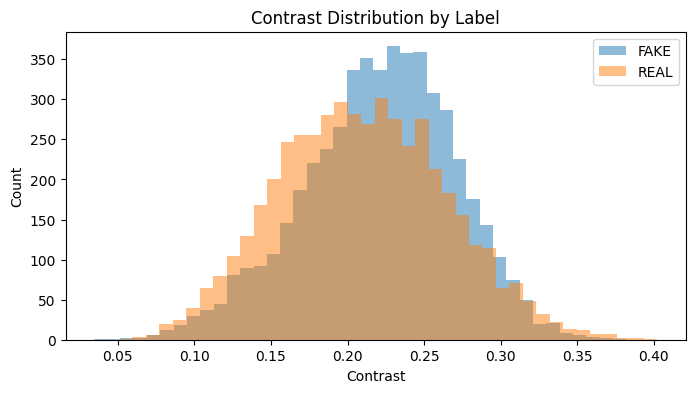

In [17]:
plt.figure(figsize=(8, 4))

for label in sorted(stats_df["label"].unique()):
    subset = stats_df[stats_df["label"] == label]
    plt.hist(subset["contrast"], bins=40, alpha=0.5, label=label)

plt.title("Contrast Distribution by Label")
plt.xlabel("Contrast")
plt.ylabel("Count")
plt.legend()
plt.show()

### 6d. Edge Strength Distribution 

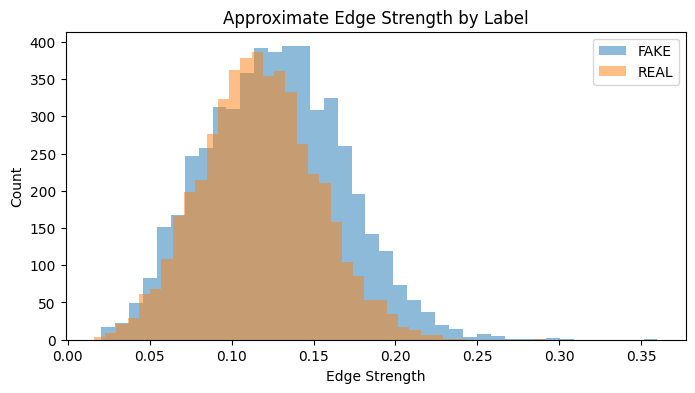

In [18]:
plt.figure(figsize=(8, 4))

for label in sorted(stats_df["label"].unique()):
    subset = stats_df[stats_df["label"] == label]
    plt.hist(subset["edge_strength"], bins=40, alpha=0.5, label=label)

plt.title("Approximate Edge Strength by Label")
plt.xlabel("Edge Strength")
plt.ylabel("Count")
plt.legend()
plt.show()

## 7. Data Loading with Keras
We create:
* Training dataset from `train/`
* Validation dataset from a 10% split of `train/`
* Test dataset from `test/`

Important:
```text

  0 = REAL
  1 = FAKE 
 
```

Keras class order is alphabetical by folder name. Since `FAKE` comes before `REAL`, we should not blindly trust the default class mapping.

To avoid ambiguity, we use `class_names=["REAL", "FAKE"]`.

In [19]:
CLASS_NAMES = ["REAL", "FAKE"]

train_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds_raw = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_ds_raw.class_names)

Found 100000 files belonging to 2 classes.
Using 90000 files for training.


I0000 00:00:1779633303.804517      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 100000 files belonging to 2 classes.
Using 10000 files for validation.
Found 20000 files belonging to 2 classes.
Class names: ['REAL', 'FAKE']


## 8. Preprocessing and Performance Pipeline 

In [20]:
normalization_layer = layers.Rescaling(1.0 / 255.0)

def preprocess_dataset(ds, training=False):
    ds = ds.map(
        lambda x, y: (normalization_layer(x), y),
        num_parallel_calls=AUTOTUNE
    )
    
    if training:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.prefetch(AUTOTUNE)
    
    return ds


train_ds = preprocess_dataset(train_ds_raw, training=True)
val_ds = preprocess_dataset(val_ds_raw, training=False)
test_ds = preprocess_dataset(test_ds_raw, training=False)

## 9. Data Augmentation 
For 32x32 images, augmentation must be moderate.

Good augmentations:
* horizontal flip
* small translation
* small rotation
* slight zoom
* slight contrast shift

Avoid aggressive crops because the images are already tiny.

In [21]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.08),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 10. Baseline Model: Simple CNN 

In [22]:
def build_simple_cnn(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)
    
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.30)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    model = keras.Model(inputs, outputs, name="simple_cnn_cifake")
    
    return model

simple_cnn = build_simple_cnn(IMG_SIZE)
simple_cnn.summary()

Model: "simple_cnn_cifake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,953 (1.17 MB)

 Trainable params: 304,801 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

## 11. Second Model: Small ResNet-Style CNN
This is the recommended primary model for CIFAKE.

Why not EfficientNet first?
* CIFAKE images are only 32x32.
* Upscaling to 224x224 adds compute without adding real information.
* A ResNet-style model trained at native resolution is efficient and strong.

In [23]:
def residual_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x
    
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x

def build_small_resnet(img_size=32):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    x = residual_block(x, 64, stride=1, dropout_rate=0.05)
    
    x = residual_block(x, 128, stride=2, dropout_rate=0.10)
    x = residual_block(x, 128, stride=1, dropout_rate=0.10)
    
    x = residual_block(x, 256, stride=2, dropout_rate=0.15)
    x = residual_block(x, 256, stride=1, dropout_rate=0.15)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    
    model = keras.Model(inputs, outputs, name="small_resnet_cifake")
    
    return model


resnet_model = build_small_resnet(IMG_SIZE)
resnet_model.summary()

Model: "small_resnet_cifake"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer_2[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      1,728 │ data_augmentatio… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 32,    │          0 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │     36,864 │ dropout_4[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     36,864 │ activation_3[0][

 Total params: 2,846,657 (10.86 MB)

 Trainable params: 2,841,665 (10.84 MB)

 Non-trainable params: 4,992 (19.50 KB)

## 12. Compile Model: ResNet Style 

In [24]:
model = resnet_model

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

## 13. Callbacks 

In [25]:
checkpoint_path = MODEL_DIR / "cifake_small_resnet_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

## 14. Train Model 

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


E0000 00:00:1779633379.197584      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/small_resnet_cifake_1/dropout_4_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779633459.340628      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7376 - auc: 0.8150 - loss: 0.5489 - precision: 0.7416 - recall: 0.7375
Epoch 1: val_auc improved from -inf to 0.00000, saving model to /kaggle/working/models/cifake_small_resnet_best.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 173s 195ms/step - accuracy: 0.7377 - auc: 0.8152 - loss: 0.5486 - precision: 0.7417 - recall: 0.7376 - val_accuracy: 0.6935 - val_auc: 0.0000e+00 - val_loss: 0.5941 - val_precision: 1.0000 - val_recall: 0.6935 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8632 - auc: 0.9371 - loss: 0.3203 - precision: 0.8624 - recall: 0.8649
Epoch 2: val_auc did not improve from 0.00000
352/352 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.8632 - auc: 0.9371 - loss: 0.3202 - precision: 0.8624 - recall: 0.8649 - val_accuracy: 0.9960 - val_auc: 0.0000e+00 - val_loss: 0.0142 - val_precision: 1.0000 - val_recall: 0.9960 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 1

## 15. Plot Training Curves 

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
1,0.871533,0.943799,0.303320,0.870814,0.873132,0.9960,0.0,0.014154,1.0,0.9960,0.0010
2,0.899600,0.963225,0.245098,0.900271,0.899233,0.9987,0.0,0.004887,1.0,0.9987,0.0010
3,0.910967,0.970315,0.219931,0.911472,0.910764,0.9911,0.0,0.026977,1.0,0.9911,0.0010
4,0.917911,0.974774,0.202588,0.917693,0.918548,0.9824,0.0,0.048430,1.0,0.9824,0.0010
5,0.934944,0.983018,0.165250,0.935399,0.934714,0.9952,0.0,0.014411,1.0,0.9952,0.0003


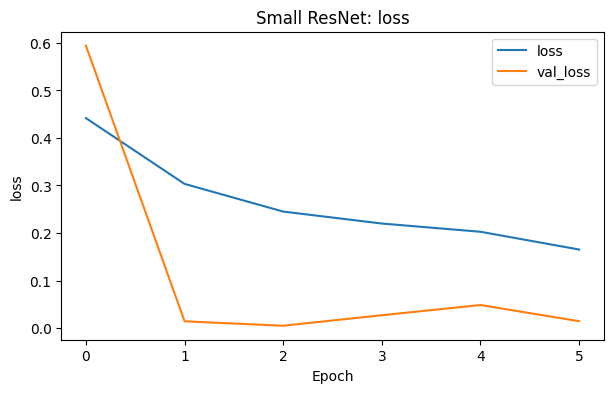

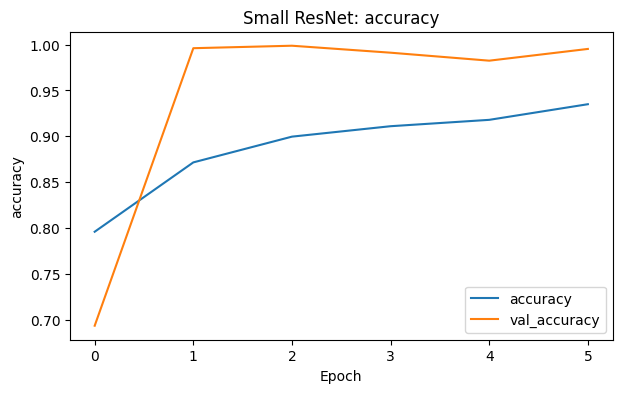

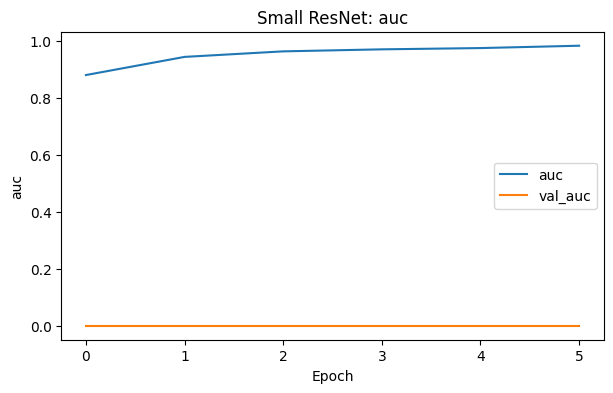

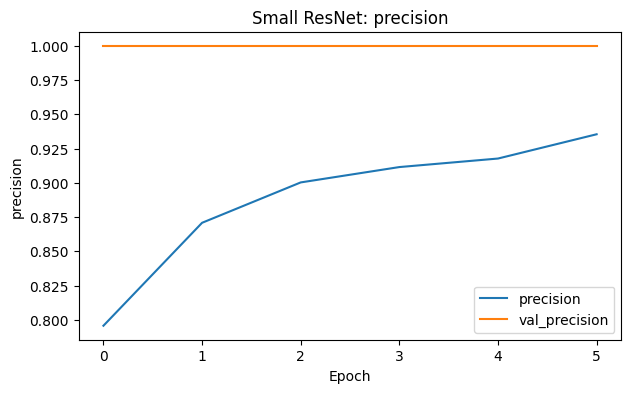

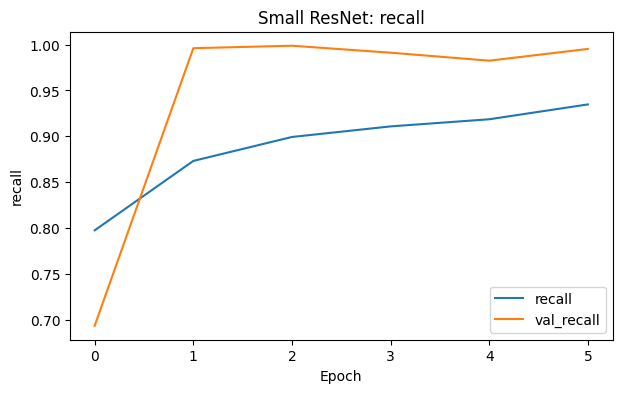

In [27]:
def plot_history(history, title_prefix="Training"):
    history_df = pd.DataFrame(history.history)
    display(history_df.tail())
    
    for metric in ["loss", "accuracy", "auc", "precision", "recall"]:
        train_metric = metric
        val_metric = f"val_{metric}"
        
        if train_metric in history_df.columns and val_metric in history_df.columns:
            plt.figure(figsize=(7, 4))
            plt.plot(history_df[train_metric], label=train_metric)
            plt.plot(history_df[val_metric], label=val_metric)
            plt.title(f"{title_prefix}: {metric}")
            plt.xlabel("Epoch")
            plt.ylabel(metric)
            plt.legend()
            plt.show()

plot_history(history, title_prefix="Small ResNet")

## 16. Compile Model: Simple CNN Baseline 

In [28]:
RUN_SIMPLE_CNN_BASELINE = False

if RUN_SIMPLE_CNN_BASELINE:
    simple_cnn = build_simple_cnn(IMG_SIZE)
    
    simple_cnn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    
    simple_checkpoint_path = MODEL_DIR / "cifake_simple_cnn_best.keras"
    
    simple_callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(simple_checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    simple_history = simple_cnn.fit(
        train_ds,
        validation_data=val_ds,
        epochs=INITIAL_EPOCHS,
        callbacks=simple_callbacks
    )
    
    plot_history(simple_history, title_prefix="Simple CNN")

## 17. Evaluation Helpers 

In [29]:
def predict_dataset(model, dataset):
    y_true = []
    y_prob = []
    
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().reshape(-1).tolist())
    
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    
    return y_true, y_prob


def evaluate_predictions(y_true, y_prob, threshold=0.5, label="Evaluation"):
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }
    
    print("=" * 80)
    print(label)
    print("=" * 80)
    
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["REAL", "FAKE"],
        zero_division=0
    ))
    
    cm = confusion_matrix(y_true, y_pred)
    
    print("Confusion Matrix:")
    print(cm)
    
    return metrics, cm

## 18. Load Best Model 

In [30]:
best_model = keras.models.load_model(checkpoint_path)

print("Loaded best model from:", checkpoint_path)

Loaded best model from: /kaggle/working/models/cifake_small_resnet_best.keras


## 19. Validation Evaluation 

In [31]:
val_y_true, val_y_prob = predict_dataset(best_model, val_ds)

val_metrics_05, val_cm_05 = evaluate_predictions(
    val_y_true,
    val_y_prob,
    threshold=0.5,
    label="Validation Results at 0.50 Threshold"
)

Validation Results at 0.50 Threshold
label: Validation Results at 0.50 Threshold
threshold: 0.5000
accuracy: 0.6935
precision: 1.0000
recall: 0.6935
f1: 0.8190
roc_auc: nan

Classification Report:
              precision    recall  f1-score   support

        REAL       0.00      0.00      0.00         0
        FAKE       1.00      0.69      0.82     10000

    accuracy                           0.69     10000
   macro avg       0.50      0.35      0.41     10000
weighted avg       1.00      0.69      0.82     10000

Confusion Matrix:
[[   0    0]
 [3065 6935]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## 20. Threshhold Tuning 

In [32]:
thresholds = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for threshold in thresholds:
    y_pred = (val_y_prob >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(val_y_true, y_pred),
        "precision": precision_score(val_y_true, y_pred, zero_division=0),
        "recall": recall_score(val_y_true, y_pred, zero_division=0),
        "f1": f1_score(val_y_true, y_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.sort_values("f1", ascending=False).head(20))

best_threshold = float(threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"])

print("Best validation threshold by F1:", best_threshold)

,threshold,accuracy,precision,recall,f1
0,0.050,0.9914,1.0,0.9914,0.995681
1,0.055,0.9891,1.0,0.9891,0.994520
2,0.060,0.9863,1.0,0.9863,0.993103
3,0.065,0.9843,1.0,0.9843,0.992088
4,0.070,0.9815,1.0,0.9815,0.990664
5,0.075,0.9776,1.0,0.9776,0.988673
6,0.080,0.9752,1.0,0.9752,0.987444
7,0.085,0.9721,1.0,0.9721,0.985853
8,0.090,0.9693,1.0,0.9693,0.984411
9,0.095,0.9662,1.0,0.9662,0.982809


Best validation threshold by F1: 0.05


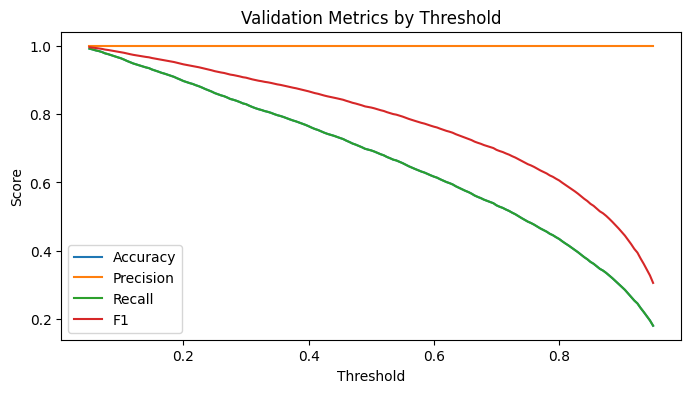

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_df["threshold"], threshold_df["accuracy"], label="Accuracy")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 21. ROC Curve and Precision-Recall Curve

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


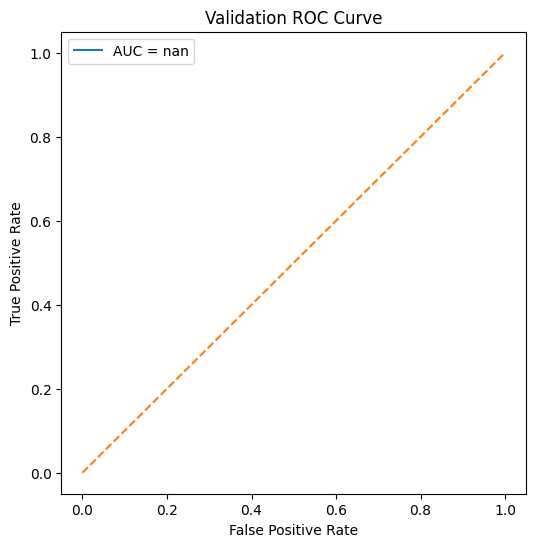

In [34]:
fpr, tpr, roc_thresholds = roc_curve(val_y_true, val_y_prob)
val_auc = roc_auc_score(val_y_true, val_y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Validation ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

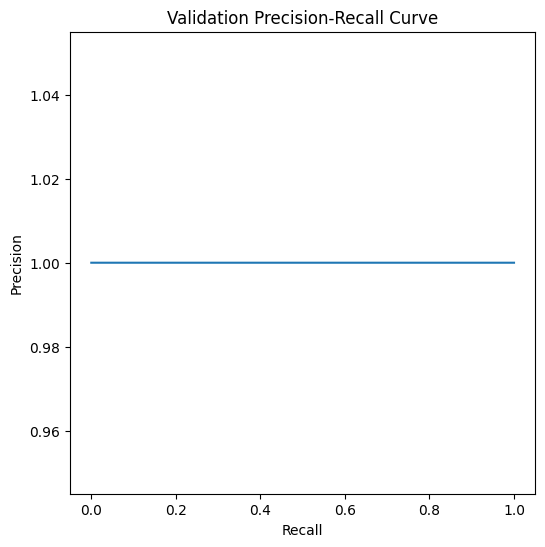

In [35]:
precision, recall, pr_thresholds = precision_recall_curve(val_y_true, val_y_prob)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision)
plt.title("Validation Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## 22. Final Test Evaluation 

In [36]:
test_y_true, test_y_prob = predict_dataset(best_model, test_ds)

test_metrics_05, test_cm_05 = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=0.5,
    label="Test Results at 0.50 Threshold"
)

test_metrics_best, test_cm_best = evaluate_predictions(
    test_y_true,
    test_y_prob,
    threshold=best_threshold,
    label=f"Test Results at Tuned Threshold {best_threshold:.3f}"
)

Test Results at 0.50 Threshold
label: Test Results at 0.50 Threshold
threshold: 0.5000
accuracy: 0.7331
precision: 0.7561
recall: 0.6882
f1: 0.7206
roc_auc: 0.8168

Classification Report:
              precision    recall  f1-score   support

        REAL       0.71      0.78      0.74     10000
        FAKE       0.76      0.69      0.72     10000

    accuracy                           0.73     20000
   macro avg       0.73      0.73      0.73     20000
weighted avg       0.73      0.73      0.73     20000

Confusion Matrix:
[[7780 2220]
 [3118 6882]]
Test Results at Tuned Threshold 0.050
label: Test Results at Tuned Threshold 0.050
threshold: 0.0500
accuracy: 0.5841
precision: 0.5464
recall: 0.9913
f1: 0.7045
roc_auc: 0.8168

Classification Report:
              precision    recall  f1-score   support

        REAL       0.95      0.18      0.30     10000
        FAKE       0.55      0.99      0.70     10000

    accuracy                           0.58     20000
   macro avg       0

## 23. Confusion-Matrix Plot 

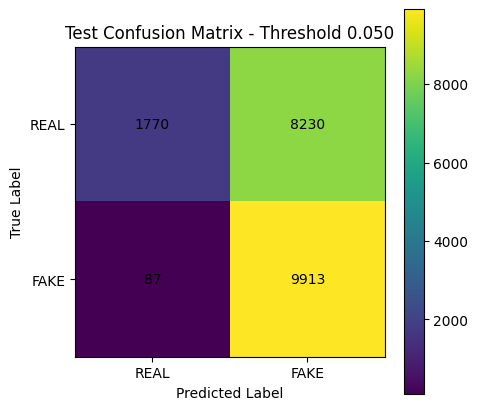

In [37]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    
    classes = ["REAL", "FAKE"]
    tick_marks = np.arange(len(classes))
    
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                horizontalalignment="center",
                verticalalignment="center"
            )
    
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


plot_confusion_matrix(
    test_cm_best,
    f"Test Confusion Matrix - Threshold {best_threshold:.3f}"
)

## 24. Probability Distribution 

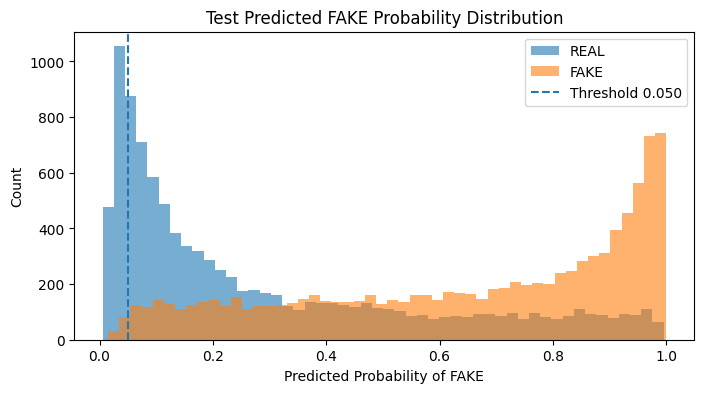

In [38]:
plt.figure(figsize=(8, 4))

plt.hist(
    test_y_prob[test_y_true == 0],
    bins=50,
    alpha=0.6,
    label="REAL"
)

plt.hist(
    test_y_prob[test_y_true == 1],
    bins=50,
    alpha=0.6,
    label="FAKE"
)

plt.axvline(best_threshold, linestyle="--", label=f"Threshold {best_threshold:.3f}")

plt.title("Test Predicted FAKE Probability Distribution")
plt.xlabel("Predicted Probability of FAKE")
plt.ylabel("Count")
plt.legend()
plt.show()

## 25. Build Test Results DataFrame 

In [39]:
test_file_paths = test_ds_raw.file_paths

test_results_df = pd.DataFrame({
    "path": test_file_paths,
    "true_label_numeric": test_y_true,
    "pred_fake_probability": test_y_prob
})

test_results_df["true_label"] = np.where(
    test_results_df["true_label_numeric"] == 1,
    "FAKE",
    "REAL"
)

test_results_df["pred_label_numeric"] = (
    test_results_df["pred_fake_probability"] >= best_threshold
).astype(int)

test_results_df["pred_label"] = np.where(
    test_results_df["pred_label_numeric"] == 1,
    "FAKE",
    "REAL"
)

test_results_df["correct"] = (
    test_results_df["true_label_numeric"] == test_results_df["pred_label_numeric"]
)

In [40]:
test_results_df.head()

,path,true_label_numeric,pred_fake_probability,true_label,pred_label_numeric,pred_label,correct
0,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.018351,REAL,0,REAL,True
1,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.231012,REAL,1,FAKE,False
2,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.086157,REAL,1,FAKE,False
3,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.170829,REAL,1,FAKE,False
4,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.869505,REAL,1,FAKE,False


In [41]:
test_results_df["correct"].value_counts()

correct
True     11683
False     8317
Name: count, dtype: int64

## 26. Error Analysis 

### 26a. False Positives and False Negatives 

In [42]:
false_positives_df = test_results_df[
    (test_results_df["true_label"] == "REAL") &
    (test_results_df["pred_label"] == "FAKE")
].copy()

false_negatives_df = test_results_df[
    (test_results_df["true_label"] == "FAKE") &
    (test_results_df["pred_label"] == "REAL")
].copy()

print("False positives: REAL predicted as FAKE:", len(false_positives_df))
print("False negatives: FAKE predicted as REAL:", len(false_negatives_df))

print("False positive rate:", len(false_positives_df) / max(1, (test_results_df["true_label"] == "REAL").sum()))
print("False negative rate:", len(false_negatives_df) / max(1, (test_results_df["true_label"] == "FAKE").sum()))

False positives: REAL predicted as FAKE: 8230
False negatives: FAKE predicted as REAL: 87
False positive rate: 0.823
False negative rate: 0.0087


### 26b. Most Confident Mistakes 

In [43]:
mistakes_df = test_results_df[~test_results_df["correct"]].copy()

mistakes_df["confidence_wrong"] = np.where(
    mistakes_df["pred_label_numeric"] == 1,
    mistakes_df["pred_fake_probability"],
    1 - mistakes_df["pred_fake_probability"]
)

display(
    mistakes_df
    .sort_values("confidence_wrong", ascending=False)
    .head(20)
)

,path,true_label_numeric,pred_fake_probability,true_label,pred_label_numeric,pred_label,correct,confidence_wrong
939,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.995438,REAL,1,FAKE,False,0.995438
6539,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.995143,REAL,1,FAKE,False,0.995143
7279,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.994378,REAL,1,FAKE,False,0.994378
6694,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.993938,REAL,1,FAKE,False,0.993938
3954,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.991980,REAL,1,FAKE,False,0.991980
2984,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.990947,REAL,1,FAKE,False,0.990947
7469,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.990929,REAL,1,FAKE,False,0.990929
3779,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.990727,REAL,1,FAKE,False,0.990727
1589,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.990704,REAL,1,FAKE,False,0.990704
2198,/kaggle/input/datasets/birdy654/cifake-real-an...,0,0.989328,REAL,1,FAKE,False,0.989328


### 26c. Show Mistakes 

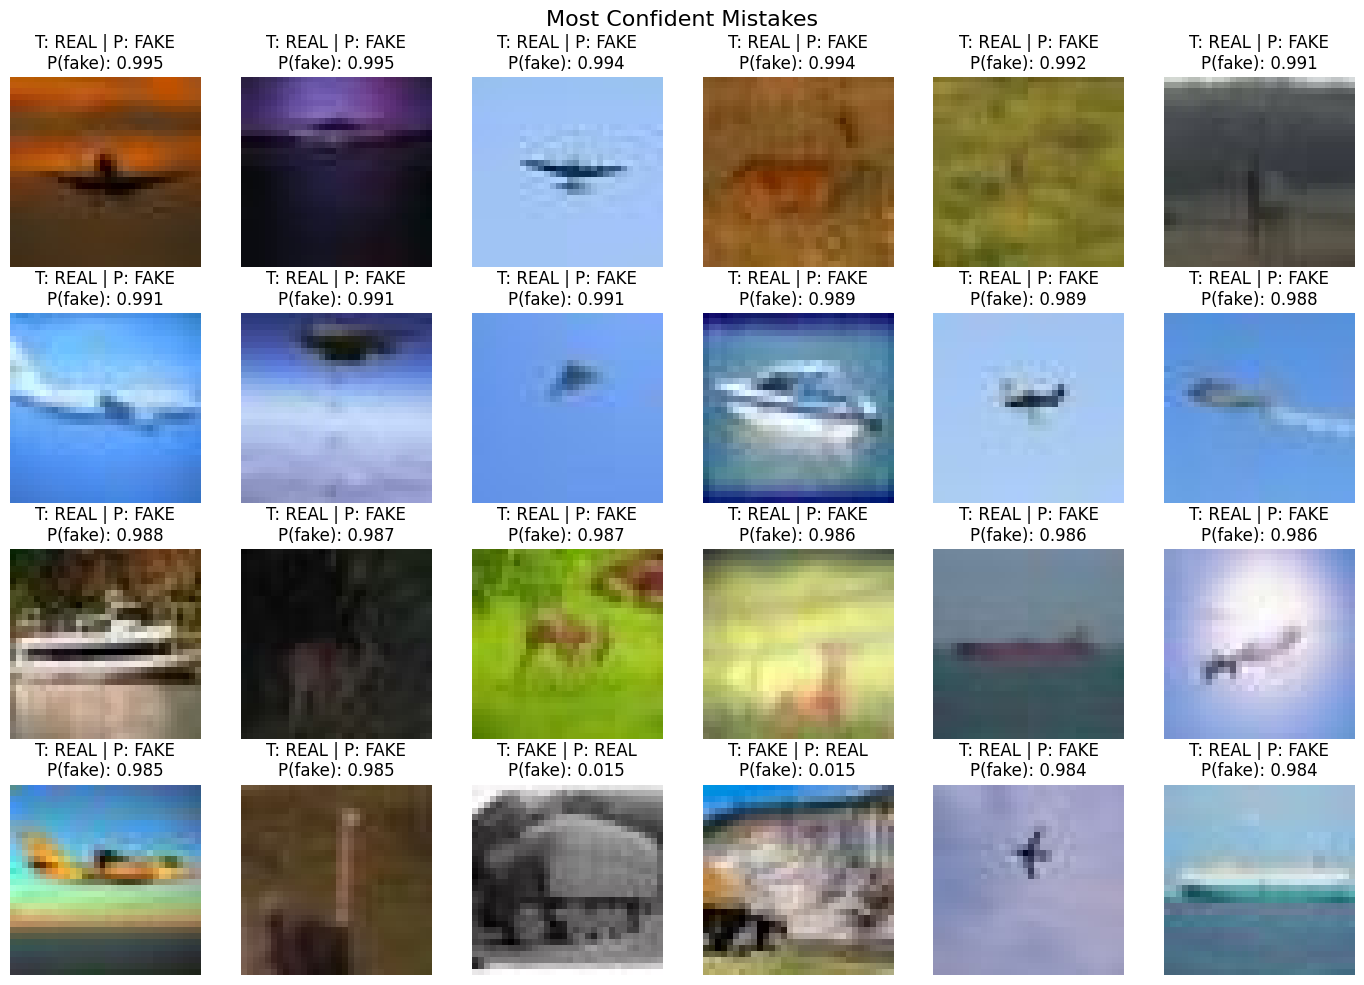

In [44]:
def show_prediction_grid(dataframe, n=24, title="Images"):
    sample_df = dataframe.head(n)
    
    if len(sample_df) == 0:
        print("No images to display.")
        return
    
    cols = 6
    rows = int(np.ceil(len(sample_df) / cols))
    
    plt.figure(figsize=(14, rows * 2.5))
    
    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = Image.open(row["path"]).convert("RGB")
        
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"T: {row['true_label']} | P: {row['pred_label']}\n"
            f"P(fake): {row['pred_fake_probability']:.3f}"
        )
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_prediction_grid(
    mistakes_df.sort_values("confidence_wrong", ascending=False),
    n=24,
    title="Most Confident Mistakes"
)

## 27. Show Correct High Confidence Predictions 

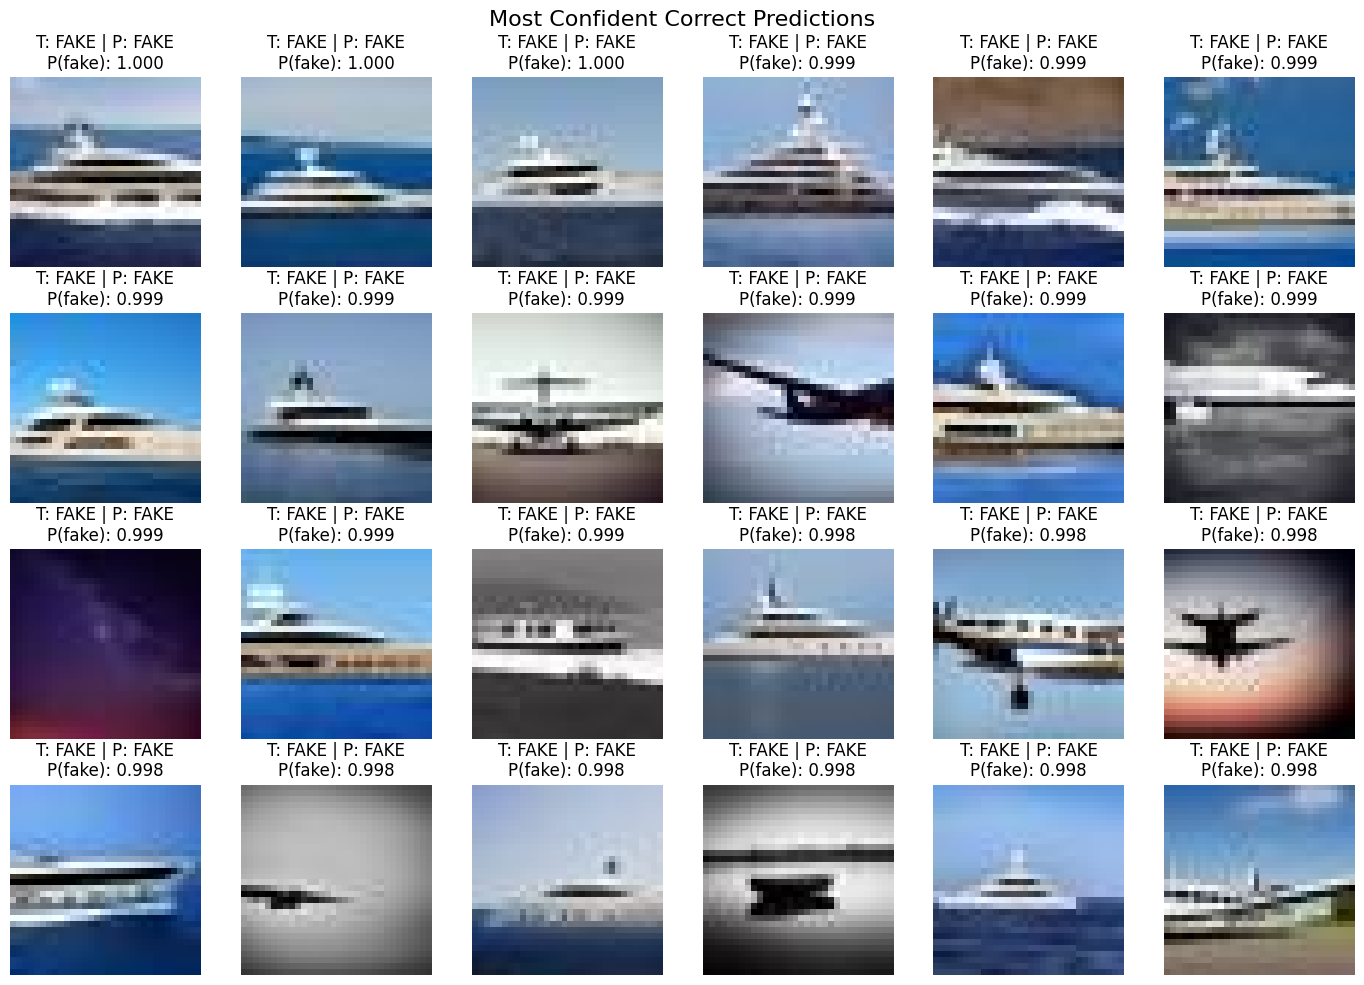

In [45]:
correct_df = test_results_df[test_results_df["correct"]].copy()

correct_df["confidence_correct"] = np.where(
    correct_df["pred_label_numeric"] == 1,
    correct_df["pred_fake_probability"],
    1 - correct_df["pred_fake_probability"]
)

show_prediction_grid(
    correct_df.sort_values("confidence_correct", ascending=False),
    n=24,
    title="Most Confident Correct Predictions"
)

## 28. Test-Time Augmentation 

In [46]:
def predict_single_image_array(model, image_path):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    prob = float(model.predict(arr, verbose=0).reshape(-1)[0])
    return prob


def predict_single_image_array_tta(model, image_path):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    
    arr_original = np.expand_dims(arr, axis=0)
    arr_flipped = np.expand_dims(np.fliplr(arr), axis=0)
    
    prob_original = float(model.predict(arr_original, verbose=0).reshape(-1)[0])
    prob_flipped = float(model.predict(arr_flipped, verbose=0).reshape(-1)[0])
    
    return (prob_original + prob_flipped) / 2


RUN_TTA = False

if RUN_TTA:
    tta_probs = []
    
    for i, path in enumerate(test_results_df["path"], start=1):
        tta_probs.append(predict_single_image_array_tta(best_model, path))
        
        if i % 1000 == 0:
            print(f"TTA predicted {i}/{len(test_results_df)}")
    
    tta_probs = np.array(tta_probs)
    
    evaluate_predictions(
        test_y_true,
        tta_probs,
        threshold=best_threshold,
        label=f"Test Results with TTA at Threshold {best_threshold:.3f}"
    )

## 29. Explainable AI: Grad-CAM

In [47]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            return layer.name
    return None


last_conv_layer_name = find_last_conv_layer_name(best_model)

print("Last conv layer:", last_conv_layer_name)

Last conv layer: conv2d_20


In [48]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = keras.Model(
        model.inputs,
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    max_value = tf.reduce_max(heatmap)
    
    if max_value == 0:
        return np.zeros_like(heatmap.numpy())
    
    heatmap = tf.maximum(heatmap, 0) / max_value
    
    return heatmap.numpy()


def load_image_for_model(path):
    img = Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return img, arr


def show_gradcam(path, model, title="Grad-CAM"):
    img, img_array = load_image_for_model(path)
    
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )
    
    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.asarray(heatmap_resized)
    
    plt.figure(figsize=(9, 3))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized)
    plt.title("Heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_resized, alpha=0.45)
    plt.title(title)
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

### 29a. Grad-CAM on Mistakes 

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


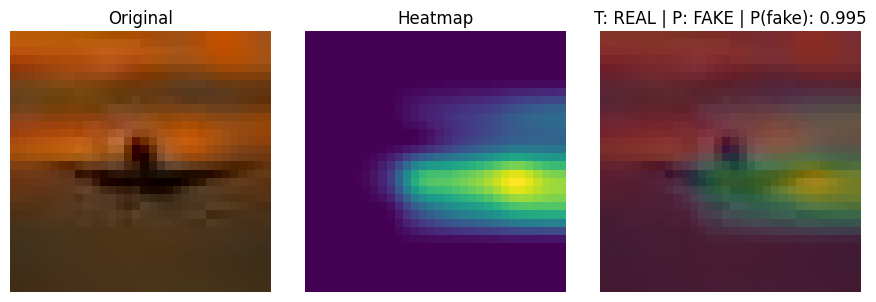

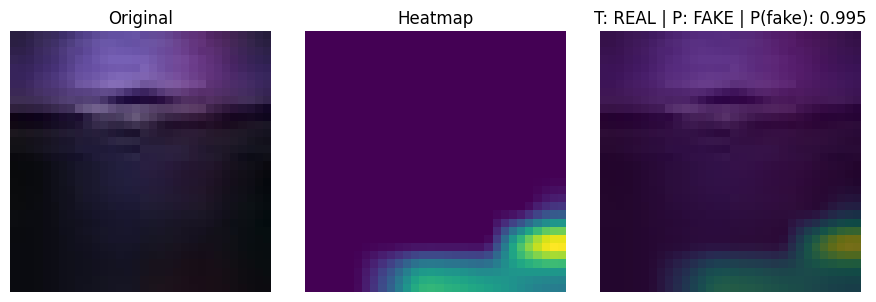

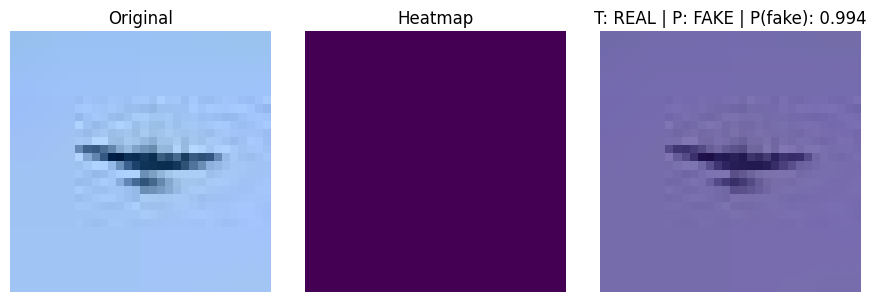

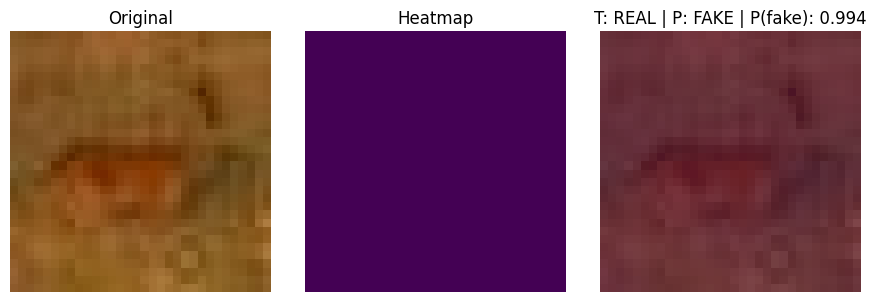

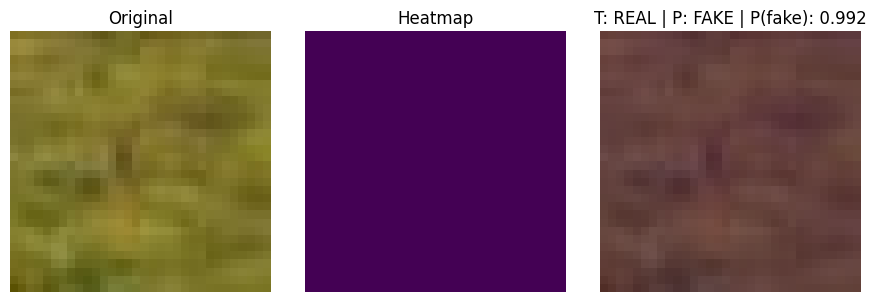

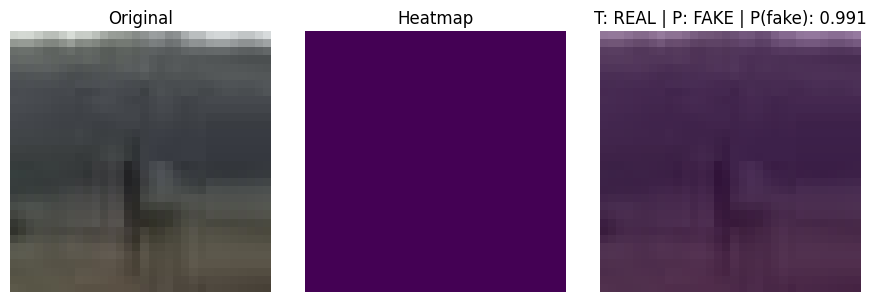

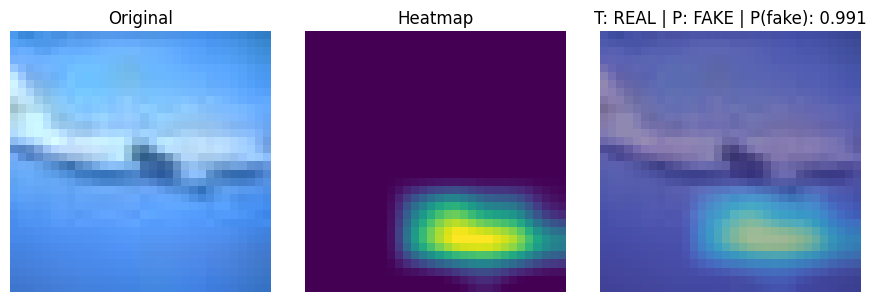

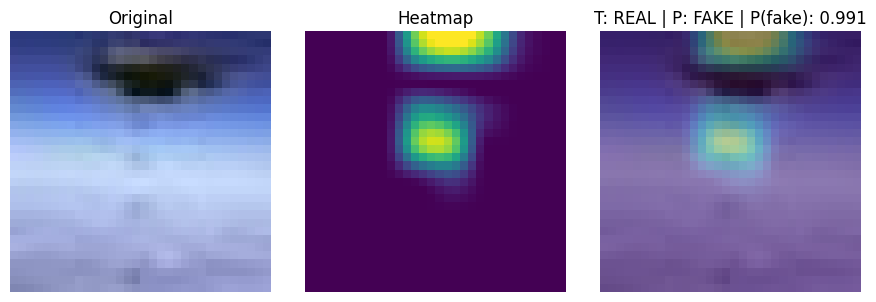

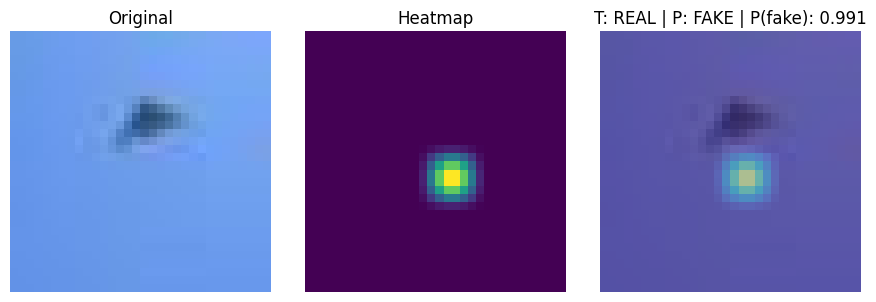

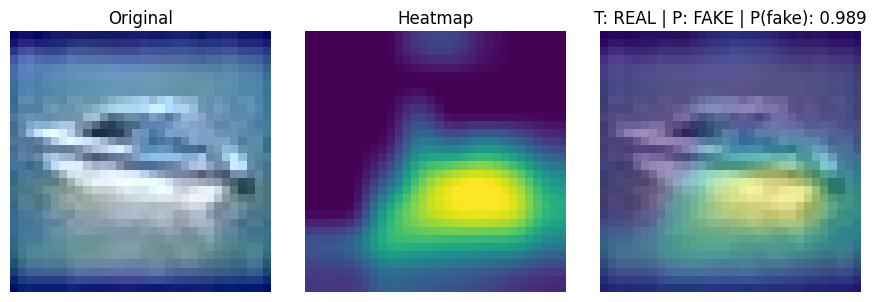

In [49]:
if last_conv_layer_name is not None:
    for _, row in mistakes_df.sort_values("confidence_wrong", ascending=False).head(10).iterrows():
        title = f"T: {row['true_label']} | P: {row['pred_label']} | P(fake): {row['pred_fake_probability']:.3f}"
        show_gradcam(row["path"], best_model, title=title)
else:
    print("No Conv2D layer found for Grad-CAM.")

### 29b. Grad-CAM on Correct Predictions 

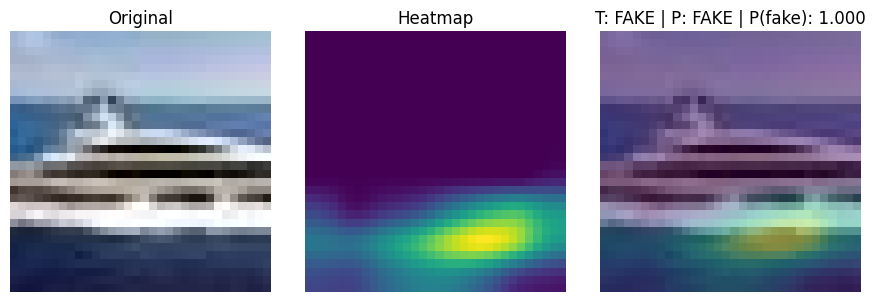

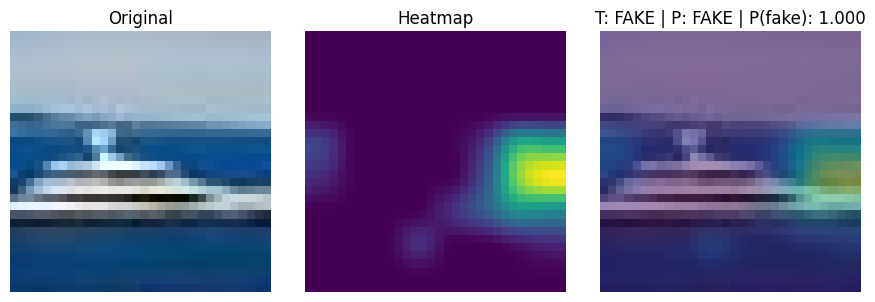

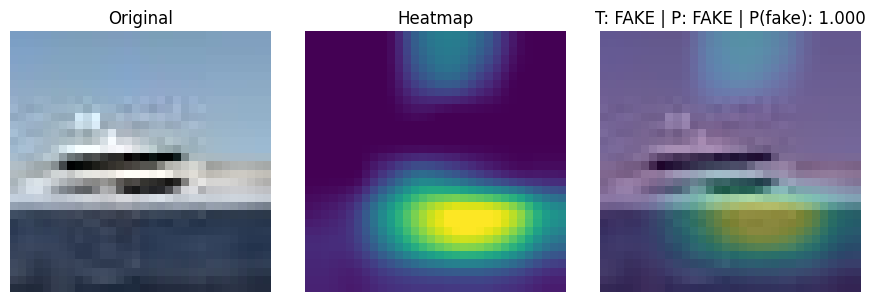

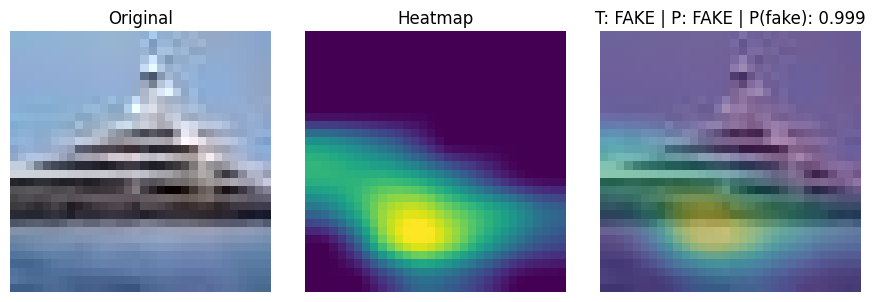

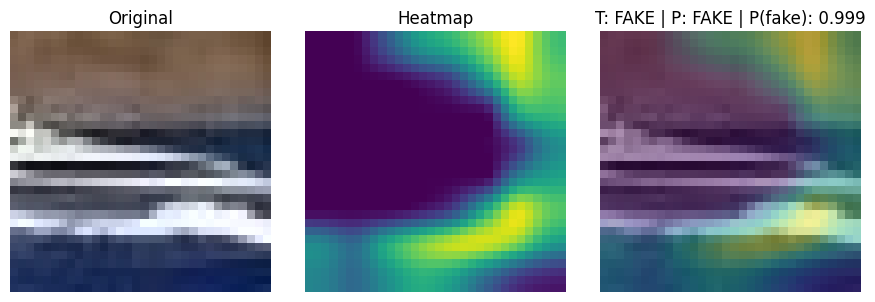

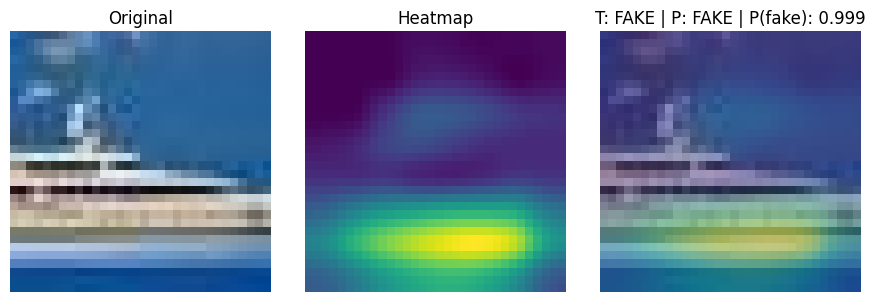

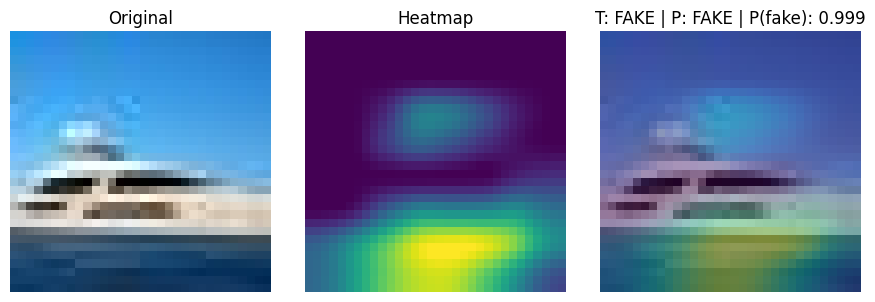

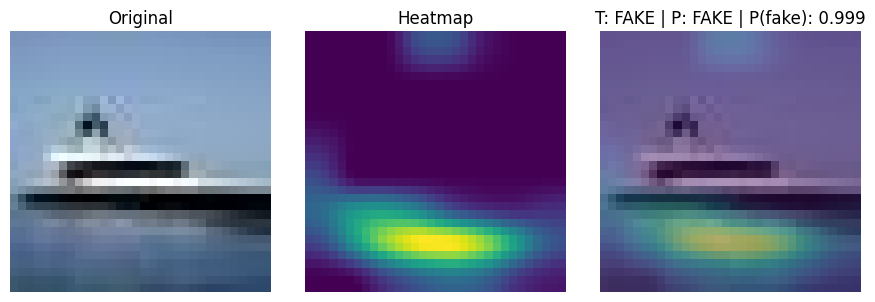

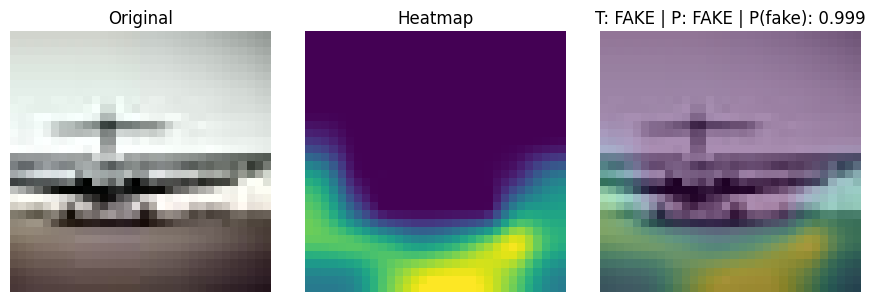

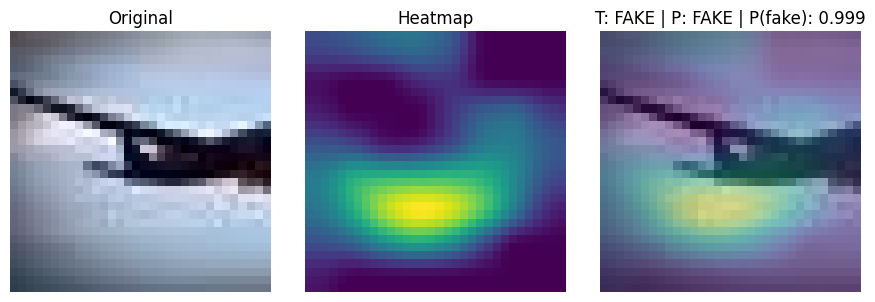

In [50]:
if last_conv_layer_name is not None:
    for _, row in correct_df.sort_values("confidence_correct", ascending=False).head(10).iterrows():
        title = f"T: {row['true_label']} | P: {row['pred_label']} | P(fake): {row['pred_fake_probability']:.3f}"
        show_gradcam(row["path"], best_model, title=title)
else:
    print("No Conv2D layer found for Grad-CAM.")

## 30. Save Model and Reports 

In [51]:
final_model_path = MODEL_DIR / "cifake_small_resnet_final.keras"

best_model.save(final_model_path)

print("Saved final model to:", final_model_path)

Saved final model to: /kaggle/working/models/cifake_small_resnet_final.keras


In [52]:
metrics_report = {
    "dataset": "CIFAKE",
    "model": "Small ResNet-style CNN",
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "validation_split": VALIDATION_SPLIT,
    "best_threshold": best_threshold,
    "validation_at_0_5": val_metrics_05,
    "test_at_0_5": test_metrics_05,
    "test_at_tuned_threshold": test_metrics_best,
    "class_mapping": {
        "REAL": 0,
        "FAKE": 1
    }
}

metrics_path = REPORT_DIR / "cifake_metrics_report.json"

with open(metrics_path, "w") as f:
    json.dump(metrics_report, f, indent=2)

print("Saved metrics report to:", metrics_path)

Saved metrics report to: /kaggle/working/reports/cifake_metrics_report.json


In [53]:
test_predictions_path = REPORT_DIR / "cifake_test_predictions.csv"

test_results_df.to_csv(test_predictions_path, index=False)

print("Saved test predictions to:", test_predictions_path)

Saved test predictions to: /kaggle/working/reports/cifake_test_predictions.csv


## 31. Inference Function for One Local Image 
This function will be useful for deployment 

{'pred_label': 'FAKE', 'pred_numeric': 1, 'prob_fake': 0.8727126121520996, 'threshold': 0.05}


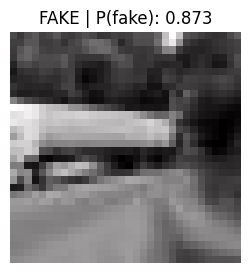

In [54]:
def predict_local_image(image_path, model, threshold=0.5):
    img = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    
    prob_fake = float(model.predict(arr, verbose=0).reshape(-1)[0])
    
    pred_numeric = int(prob_fake >= threshold)
    pred_label = "FAKE" if pred_numeric == 1 else "REAL"
    
    return {
        "pred_label": pred_label,
        "pred_numeric": pred_numeric,
        "prob_fake": prob_fake,
        "threshold": threshold
    }


sample_path = test_results_df.sample(1, random_state=SEED)["path"].iloc[0]

result = predict_local_image(sample_path, best_model, threshold=best_threshold)

print(result)

img = Image.open(sample_path).convert("RGB")

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis("off")
plt.title(f"{result['pred_label']} | P(fake): {result['prob_fake']:.3f}")
plt.show()

In [55]:
def deployed_predict(image_path, model_path=final_model_path, threshold=0.5):
    loaded_model = keras.models.load_model(model_path)
    
    result = predict_local_image(
        image_path=image_path,
        model=loaded_model,
        threshold=threshold
    )
    
    response = {
        "label": result["pred_label"],
        "probability_fake": result["prob_fake"],
        "threshold": result["threshold"],
        "model_name": "cifake_small_resnet"
    }
    
    return response


deployed_predict(sample_path, model_path=final_model_path, threshold=best_threshold)

{'label': 'FAKE',
 'probability_fake': 0.8727126121520996,
 'threshold': 0.05,
 'model_name': 'cifake_small_resnet'}

## 